# MMCS Analysis

In [2]:
import numpy as np


def load_data(model_name, which, K):
    data_path = f"mmcs_results/{model_name}/{which}_K{K}.npy"
    data = np.load(data_path, allow_pickle=True)
    return data


def get_changes(clusters):
    changes = []
    prev = None

    for i, c in enumerate(clusters):
        if prev is not None:
            if prev != c:
                changes.append(i)
        else:
            changes.append(i)
        prev = c

    return changes


clusters = {
    "pythia-160m": {
        1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        2: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
        3: [0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2],
        4: [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3],
        5: [0, 0, 0, 4, 4, 1, 1, 2, 2, 3, 3],
        6: [0, 0, 5, 4, 4, 1, 1, 2, 2, 3, 3],
    },
    "pythia-410m": {
        1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
        3: [2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
        4: [2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        5: [0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 1, 1, 1, 1, 1, 4, 4, 4, 2, 2, 2, 2],
        6: [5, 5, 5, 1, 1, 1, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 4, 4, 4, 2, 2, 2, 2],
        7: [5, 5, 5, 0, 0, 0, 0, 1, 1, 1, 1, 6, 6, 3, 3, 3, 4, 4, 4, 2, 2, 2, 2],
        8: [2, 2, 2, 5, 5, 7, 7, 1, 1, 1, 1, 6, 6, 3, 3, 3, 4, 4, 4, 0, 0, 0, 0],
        9: [2, 2, 2, 5, 5, 7, 7, 0, 0, 0, 0, 6, 6, 3, 3, 3, 1, 1, 1, 8, 8, 4, 4],
    },
    "pythia-1b": {
        1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
        3: [1, 1, 1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0],
        4: [0, 0, 0, 0, 0, 2, 2, 2, 2, 1, 1, 1, 1, 3, 3],
        5: [4, 4, 1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 3, 3],
        6: [4, 4, 1, 1, 1, 0, 0, 0, 0, 2, 2, 5, 5, 3, 3],
    },
}

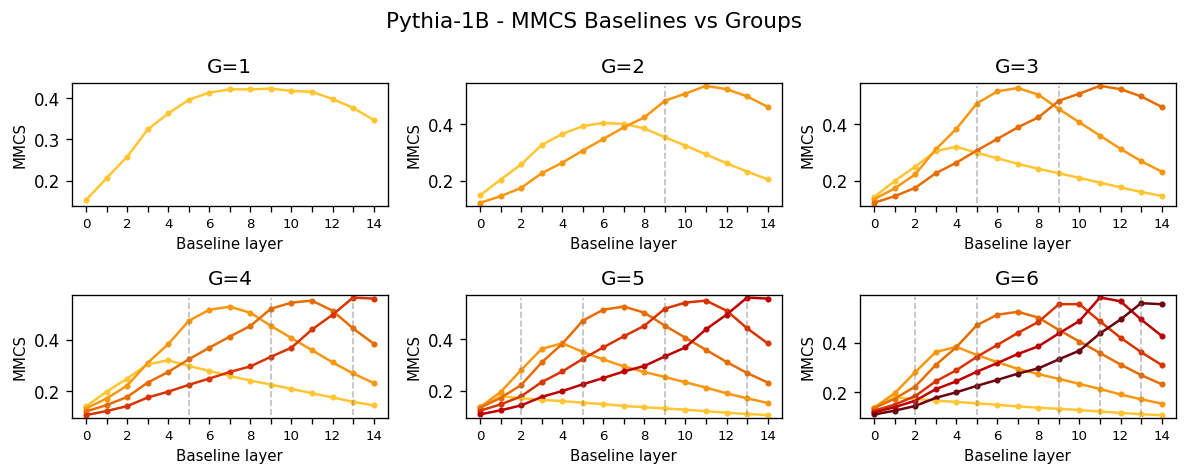

In [7]:
import matplotlib.pyplot as plt
from group_sae.utils import cmap

model_name = "pythia-1b"
max_G = len(clusters[model_name])

n_rows = len(clusters[model_name]) // 3
fig, ax = plt.subplots(n_rows, 3, figsize=(10, 2 * n_rows), dpi=120, layout="tight")
updated_palette = cmap(np.linspace(0, 1, max_G))

for G in range(1, max_G + 1):
    ymin = 1
    ymax = 0
    j = G - 1

    data = load_data(model_name, "baseline", G)

    for k, i in enumerate(get_changes(clusters[model_name][G])):
        ax[j // 3, j % 3].plot(
            data[:, i], label=f"Cluster {clusters[model_name][G][i]}", c=updated_palette[k]
        )
        ax[j // 3, j % 3].scatter(
            np.arange(len(data[:, i])),
            data[:, i],
            color=updated_palette[k],
            s=7,
        )

        xticks = np.arange(len(data[:, i]))
        xticks = [str(x) if i % 2 == 0 else "" for i, x in enumerate(xticks)]
        ax[j // 3, j % 3].set_title(f"G={G}", fontsize=12)
        ax[j // 3, j % 3].set_xlabel("Baseline layer", fontsize=9)
        ax[j // 3, j % 3].set_xticks(np.arange(len(data[:, i])))
        ax[j // 3, j % 3].set_xticklabels(xticks, fontsize=8)
        ax[j // 3, j % 3].set_ylabel("MMCS", fontsize=9)

        ymin_ = min(data[:, i])
        ymax_ = max(data[:, i])

        if ymin_ < ymin:
            ymin = ymin_
        if ymax_ > ymax:
            ymax = ymax_

    for i in get_changes(clusters[model_name][G])[1:]:
        ax[j // 3, j % 3].vlines(
            x=i,
            ymin=ymin,
            ymax=ymax,
            color="gray",
            linestyle="--",
            alpha=0.5,
            linewidth=1,
        )
        ax[j // 3, j % 3].set_ylim(ymin - 0.01, min(0.6, ymax + 0.01))

plt.suptitle(f"{model_name.title()} - MMCS Baselines vs Groups", fontsize=13)
plt.savefig(
    f"img/mmcs-{model_name}.png",
    dpi=300,
    bbox_inches="tight",
)